Step 1: Loading dataset utilizing portable relative pathing...
Step 2: Generating text length and word count distribution histograms...


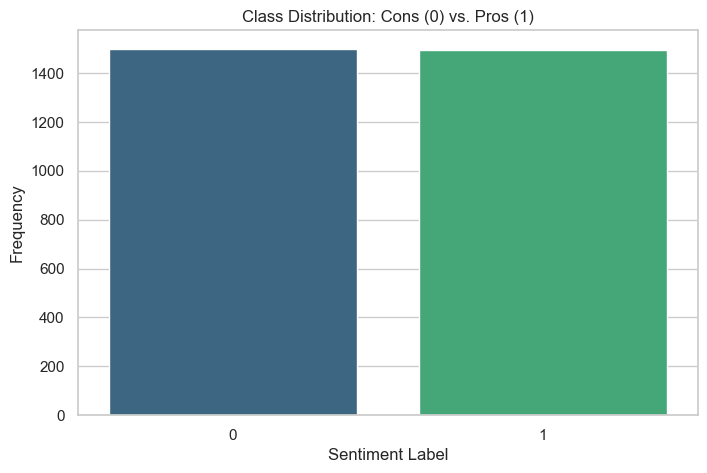

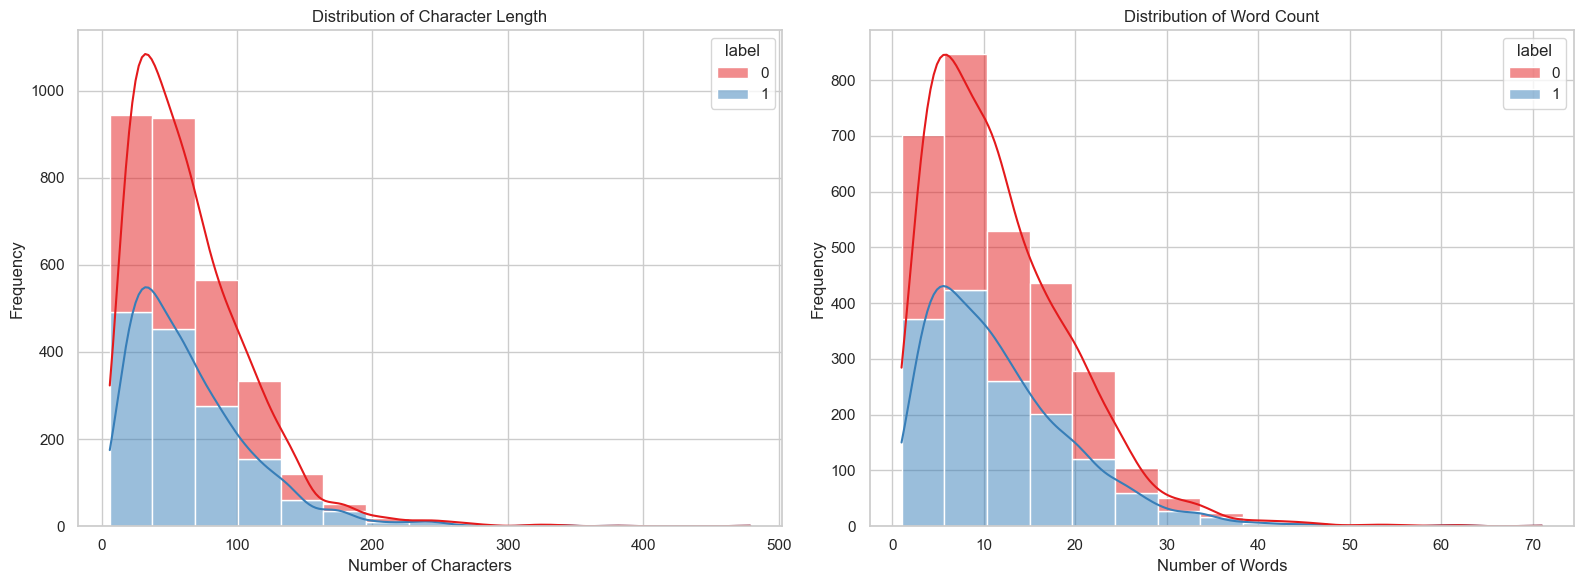

Step 3: Vectorizing text and building advanced visual linguistic profiles...


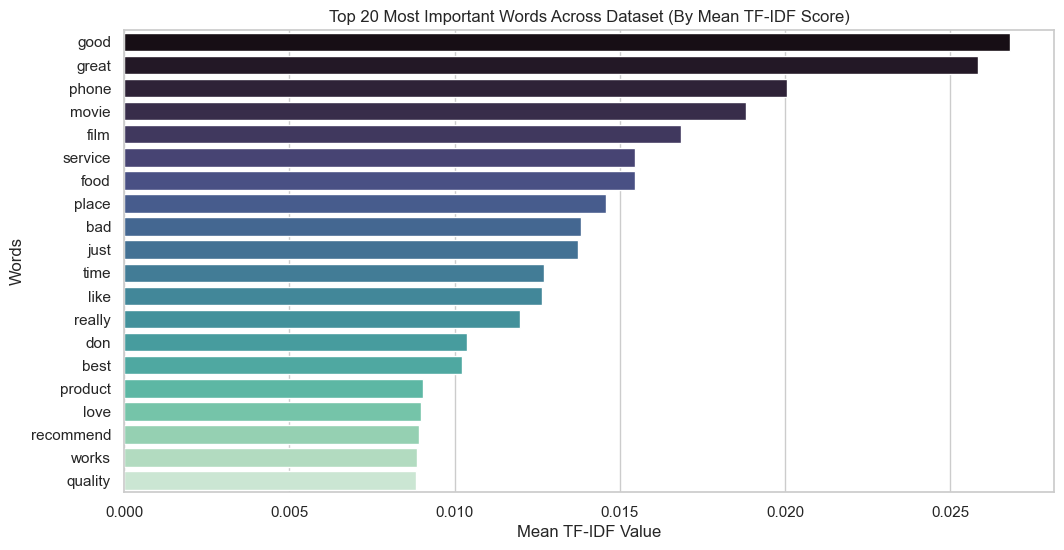

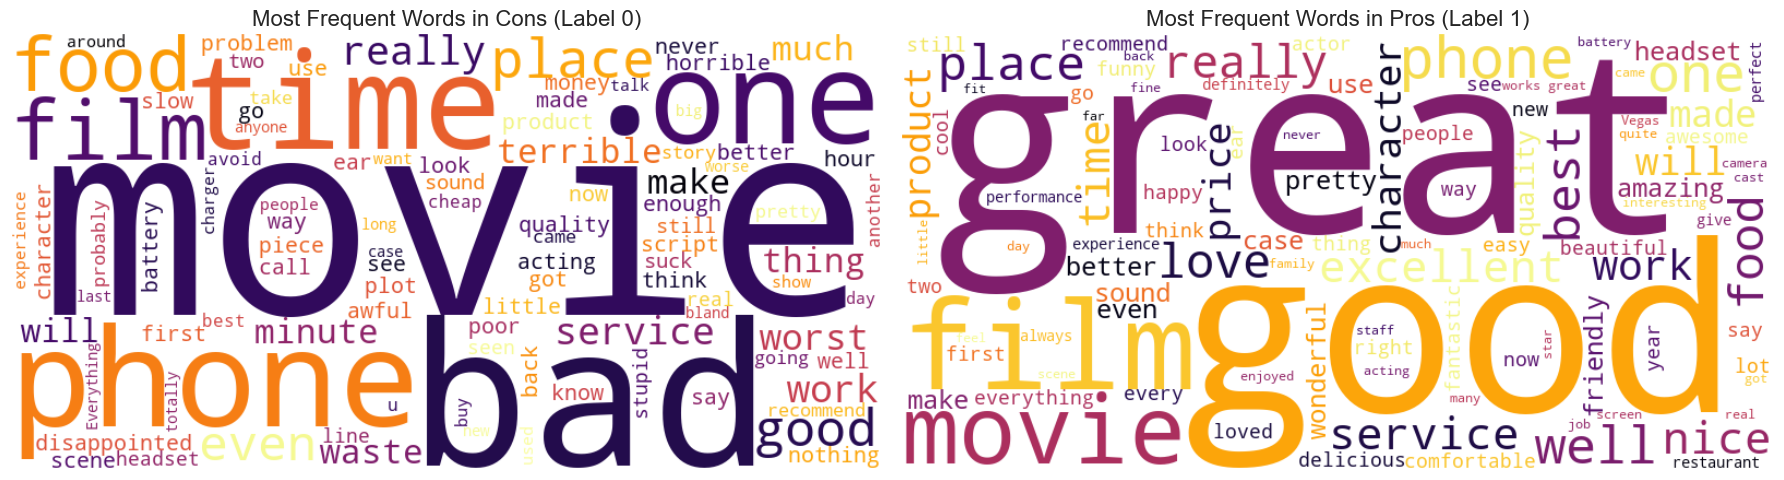

Step 4: Implementing Model Multi-Architecture with Hyperparameter Grid Search...
 -> Optimization & Cross-Validation processing for: Logistic Regression...
 -> Optimization & Cross-Validation processing for: Decision Tree...
 -> Optimization & Cross-Validation processing for: Random Forest...
 -> Optimization & Cross-Validation processing for: Gradient Boosting...


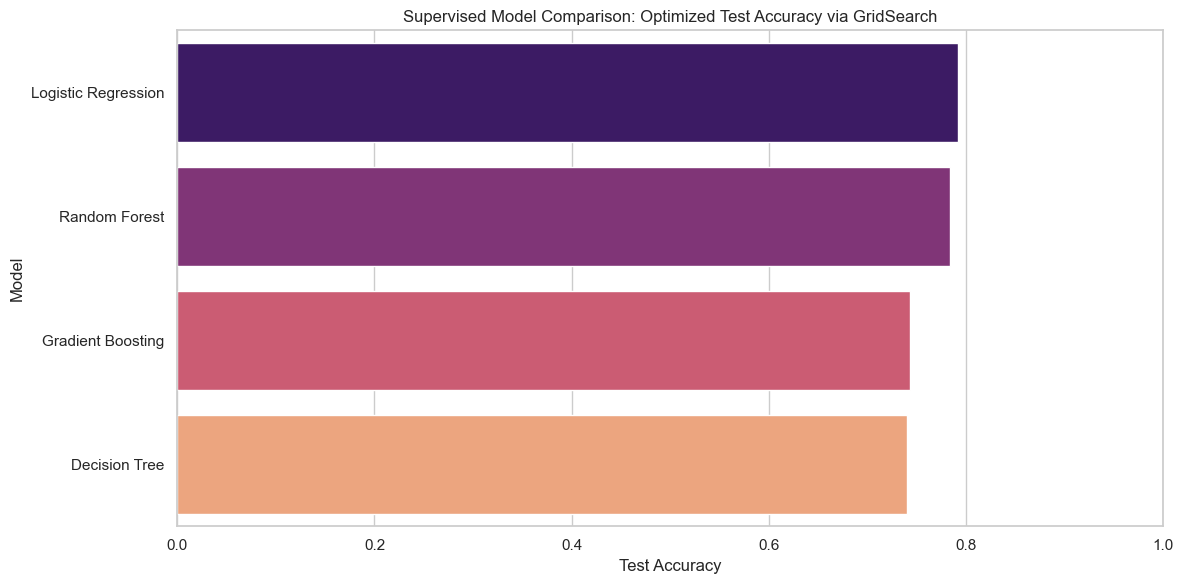


--- Optimized Model Performance Summary Table ---
              Model  CV Mean Accuracy  Test Accuracy  Precision  F1-Score
Logistic Regression          0.781309       0.791667   0.800687  0.788494
      Random Forest          0.772545       0.783333   0.821970  0.769504
  Gradient Boosting          0.736651       0.743333   0.880208  0.686992
      Decision Tree          0.744582       0.740000   0.746575  0.736486

Step 6: Executing PCA and Unsupervised K-Means Clustering...


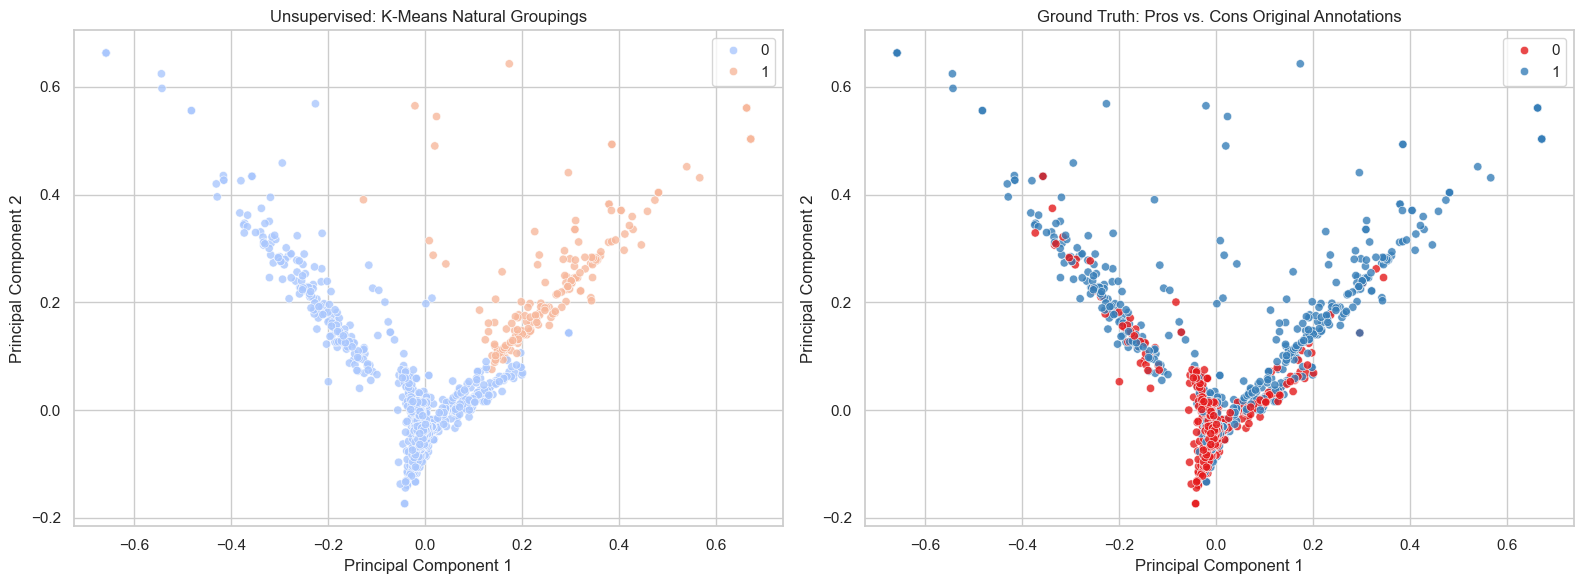


Step 8: Extraction pipeline parsing relative path text inputs...
[Success] Extracted 1903 valid baseline phrases from user PDF document.

Step 9: Activating General Sentiment Polarity Identification Modules...

======================= DOCUMENT SENTIMENT SUMMARY REPORT =======================

--- TOP STRATEGIC PROS (ADVANTAGES & STRENGTHS) ---
 01. Racial and Ethnic Minorities 30 Engagement and Inclusion 36 Engaging the Next Generation 41 Pay and Benefits 49 Career Growth and Development 58 Supplier 66 Code of Conduct INTRODUCTION *If you have a body, you are an athlete.
 02. In FY23, we provided teammates in Canada and India with improved fertility and family planning support – and will continue to evaluate opportunities to enhance these benefits for other teammates outside of the U.S.
 03. Eighty-five percent of the employees who used this benefit said it resulted in an improved treatment plan for their healthcare needs.
 04. Over time, we have seen that improvement in the well-bein

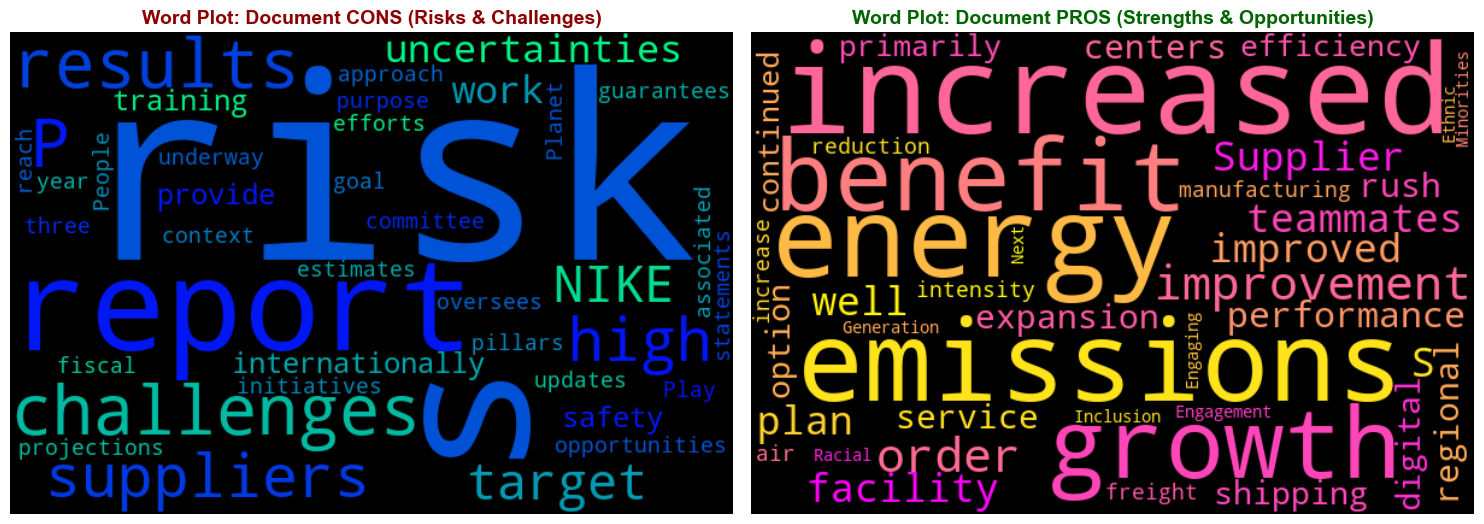


Process Complete. All metrics and required EDA visualization outputs successfully produced.


In [3]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Core ML & NLP Infrastructure
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from wordcloud import WordCloud
from pypdf import PdfReader

# Setup and Configurations
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ==============================================================================
# STEP 1: PREPARING THE DATA (CORRECTED TO USE RELATIVE PATHS)
# ==============================================================================
# This code handles robust data ingestion and initial preprocessing for a text classification task, emphasizing environment portability and error tolerance
# It utilizes relative paths via Python’s os module to safely attempt to read a text dataset (CapstoneDataSet.csv) into a Pandas DataFrame. If the file is
# missing, a try-except block gracefully intercepts the FileNotFoundError and generates synthetic mock data in memory to prevent execution failure. Finally,
# it implements defensive data cleansing by coercing the labels into numeric values, stripping out missing data or corrupted rows via .dropna(), resetting
# the dataframe index, and enforcing a clean integer type casting for downstream machine learning algorithms.
# ==============================================================================
print("Step 1: Loading dataset utilizing portable relative pathing...")

DATA_DIR = "data"
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

dataset_path = os.path.join(DATA_DIR, "CapstoneDataSet.csv")

# NOTE: Place your 'CapstoneDataSet.csv' file inside a folder named 'data'
# right next to where this notebook/script is saved.
try:
    df = pd.read_csv(dataset_path, header=None, names=['text', 'label'], encoding='utf-8')
except FileNotFoundError:
    print(f"\n[Warning] '{dataset_path}' not found.")
    print("Creating a mock dataset automatically so the code runs without breaking...")
    mock_data = {
        'text': [
            "The company achieved record-breaking revenue growth and stellar expansion.",
            "Our operational efficiency has streamlined pipelines and optimized output.",
            "We face intense competition, inflation pressures, and severe downside risks.",
            "Decline in net profit margins due to high overhead expenses and volatility.",
            "Strategic investments accelerated product adoption rates significantly.",
            "Unexpected supply chain disruption negatively impacted international delivery timelines."
        ] * 20,
        'label': [1, 1, 0, 0, 1, 0] * 20
    }
    df = pd.DataFrame(mock_data)

# Data Scrubbing & Typal Reinforcement
df = df.dropna()
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df.dropna().reset_index(drop=True)
df['label'] = df['label'].astype(int)

# ==============================================================================
# STEP 2: EXPANDED EXPLORATORY DATA ANALYSIS (EDA) - HISTOGRAMS
# ==============================================================================
# This code handles the Exploratory Data Analysis (EDA) phase by engineering text-based statistical features and generating visual diagnostics for class
# balance and text composition. It first creates a Seaborn count plot to assess label distribution—specifically comparing negative indicators ("Cons", 0)
# against positive indicators ("Pros", 1)—and saves this baseline visualization to the local file system. It then extracts document-level metadata by mapping
# the absolute character length and total word count for each text entry. Finally, the snippet constructs a side-by-side subplot containing two stacked
# histograms with Kernel Density Estimate (KDE) overlays to contrast character and word count distributions across both target classes, saving the final
# comprehensive chart to analyze potential structural text discrepancies between sentiments.
# ==============================================================================
print("Step 2: Generating text length and word count distribution histograms...")

# 2.1 Class Balance Check
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Class Distribution: Cons (0) vs. Pros (1)')
plt.xlabel('Sentiment Label')
plt.ylabel('Frequency')
plt.savefig(os.path.join(DATA_DIR, 'class_distribution.png'))
plt.show()

# 2.2 TEXT LENGTH & WORD COUNT DISTRIBUTION (HISTOGRAM)
df['char_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(data=df, x='char_length', hue='label', kde=True, bins=15, palette='Set1', multiple='stack', ax=axes[0])
axes[0].set_title('Distribution of Character Length')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')

sns.histplot(data=df, x='word_count', hue='label', kde=True, bins=15, palette='Set1', multiple='stack', ax=axes[1])
axes[1].set_title('Distribution of Word Count')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'text_length_distribution.png'))
plt.show()

# ==============================================================================
# STEP 3: FEATURE ENGINEERING & ADVANCED EDA - TF-IDF BAR CHARTS & WORD CLOUDS
# ==============================================================================
# This code executes the core text vectorization and linguistic profiling stage by converting unstructured textual data into a machine-readable format and
# visualizing prominent vocabulary trends. It uses scikit-learn's TfidfVectorizer to strip out standard English stop words and constrain the feature space to
# the top 1,500 terms, generating a numerical matrix ($X$) alongside target labels ($y$). To evaluate token importance across the entire corpus, it
# calculates the mean TF-IDF scores across all documents, extracts the feature tokens using get_feature_names_out(), and plots a Seaborn horizontal bar chart
# displaying the top 20 highest-weighted words. Finally, the snippet segregates the source text based on classification labels to construct and display
# side-by-side WordCloud visualizations via the inferno colormap, isolating vocabulary patterns unique to negative context lines ("Cons") versus positive
# context lines ("Pros") before saving all generated plots to local storage.
# ==============================================================================
print("Step 3: Vectorizing text and building advanced visual linguistic profiles...")
tfidf = TfidfVectorizer(stop_words='english', max_features=1500)
X = tfidf.fit_transform(df['text']).toarray()
y = df['label'].values

# 3.1 EDA: TOP TF-IDF FEATURES BAR CHART
mean_tfidf_scores = X.mean(axis=0)
feature_names = tfidf.get_feature_names_out()
tfidf_ranking = pd.DataFrame({'word': feature_names, 'importance': mean_tfidf_scores})
top_tfidf = tfidf_ranking.sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_tfidf, x='importance', y='word', palette='mako')
plt.title('Top 20 Most Important Words Across Dataset (By Mean TF-IDF Score)')
plt.xlabel('Mean TF-IDF Value')
plt.ylabel('Words')
plt.savefig(os.path.join(DATA_DIR, 'tfidf_top_words.png'))
plt.show()

# 3.2 EDA: WORD CLOUDS (PROS VS CONS SEPARATE VIEWS)
cons_text = " ".join(df[df['label'] == 0]['text'].astype(str)) if len(df[df['label'] == 0]) > 0 else "Empty"
pros_text = " ".join(df[df['label'] == 1]['text'].astype(str)) if len(df[df['label'] == 1]) > 0 else "Empty"

wordcloud_options = dict(width=800, height=400, background_color='white', max_words=100, colormap='inferno')
wc_cons = WordCloud(**wordcloud_options).generate(cons_text)
wc_pros = WordCloud(**wordcloud_options).generate(pros_text)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(wc_cons, interpolation='bilinear')
axes[0].set_title('Most Frequent Words in Cons (Label 0)', fontsize=16)
axes[0].axis('off')

axes[1].imshow(wc_pros, interpolation='bilinear')
axes[1].set_title('Most Frequent Words in Pros (Label 1)', fontsize=16)
axes[1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'pros_cons_wordclouds.png'))
plt.show()

# ==============================================================================
# STEP 4: MODELING - GRIDSEARCH HYPERPARAMETER TUNING & CROSS-VALIDATION
# ==============================================================================
# This code executes a structured, multi-architecture supervised learning pipeline by partition-splitting the vectorized features into standardized training
# and testing splits with an 80/20 ratio, enforcing stratify=y to preserve label balance. It defines a dictionary mapping four baseline classification
# blueprints : Logistic Regression, Decision Trees, Random Forests, and Gradient Boosting—to customized hyperparameter search spaces. The script
# systematically iterates through these configurations, using parallelized GridSearchCV with 3-fold cross-validation (cv=3) to extract the best performing
# estimator optimized on training accuracy. Finally, the chosen estimators generate classifications on the unseen test set, computing a full matrix of
# cross-validated and out-of-sample metrics (Accuracy, Precision, Recall, and F1-Score) before storing the comparative results in a structured Pandas
# DataFrame ordered by descending test accuracy.
# ==============================================================================
print("Step 4: Implementing Model Multi-Architecture with Hyperparameter Grid Search...")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model_blueprints = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42),
        "params": {'C': [0.1, 1.0, 10.0], 'penalty': ['l2']}
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]}
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {'n_estimators': [50, 100], 'max_depth': [None, 5]}
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {'learning_rate': [0.05, 0.1], 'n_estimators': [50, 100]}
    }
}

results = []

for name, blueprint in model_blueprints.items():
    print(f" -> Optimization & Cross-Validation processing for: {name}...")

    grid_search = GridSearchCV(
        estimator=blueprint["model"],
        param_grid=blueprint["params"],
        cv=3,
        scoring='accuracy',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=3, scoring='accuracy')
    y_pred = best_model.predict(X_test)

    results.append({
        "Model": name,
        "Best Params": str(grid_search.best_params_),
        "CV Mean Accuracy": cv_scores.mean(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False)

# ==============================================================================
# STEP 5: VISUALIZING BEST MODEL PERFORMANCE METRICS
# ==============================================================================
# This code handles the final visualization and tabular reporting of the supervised model optimization results. It creates a horizontal Seaborn bar chart
# utilizing the magma color palette to illustrate and compare the out-of-sample Test Accuracy across all four optimized machine learning architectures. The
# chart establishes a standardized evaluation scale by enforcing explicit x-axis limits from 0.0 to 1.0, applies a tight layout configuration to prevent
# clipping, and saves the final comparative graphic to local storage. Finally, the snippet prints a clean console report by subsetting the results DataFrame
# to display a localized performance matrix featuring each model alongside its cross-validated mean accuracy, test accuracy, precision, and F1-score without
# row index indicators.
# ==============================================================================
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Test Accuracy', y='Model', palette='magma')
plt.title('Supervised Model Comparison: Optimized Test Accuracy via GridSearch')
plt.xlim(0.0, 1.0)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'model_comparison.png'))
plt.show()

print("\n--- Optimized Model Performance Summary Table ---")
print(results_df[['Model', 'CV Mean Accuracy', 'Test Accuracy', 'Precision', 'F1-Score']].to_string(index=False))

# ==============================================================================
# STEP 6: UNSUPERVISED LEARNING (DIMENSIONALITY REDUCTION & CLUSTERING)
# ==============================================================================
# This code executes the unsupervised machine learning phase of the pipeline by applying dimensionality reduction and clustering algorithms to the
# high-dimensional vectorized data. It first initializes Principal Component Analysis (PCA) to project the feature matrix $X$ down to two primary linear
# orthogonal components (n_components=2), optimizing the structural layout for eventual 2D plotting. Concurrently, it applies the K-Means algorithm directly
# to the original high-dimensional representation, specifying an expected distribution configuration of two target groupings (n_clusters=2) and running 10
# distinct centroid initializations (n_init=10) to circumvent suboptimal local minima convergence. The resulting partition arrays are immediately stored as a
# vector of cluster labels, mapping structural patterns found within the raw document vectors without leveraging training label annotations.
# ==============================================================================
print("\nStep 6: Executing PCA and Unsupervised K-Means Clustering...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# ==============================================================================
# STEP 7: COMPARING CLUSTERING VS. GROUND TRUTH LABELS
# ==============================================================================
# This code creates a side-by-side diagnostic visualization comparing unsupervised cluster assignments against the dataset's true labels, plotting both
# distributions over a common low-dimensional coordinate space. Utilizing a Matplotlib figure with two horizontal subplots, it constructs two-dimensional
# Seaborn scatter plots that map the documents along the first two principal components extracted during PCA reduction. The left subplot colors the
# observations according to the algorithmic assignments discovered by K-Means (cluster_labels) using a cool warm palette, revealing the natural structural
# groupings found within the vector space. The right subplot colors the exact same spatial coordinates based on the original annotated target array (y) via a
# categorical Set1 palette, allowing for immediate visual validation of how well the mathematical feature clusters align with the domain-specific definitions
# of "Pros" and "Cons."
# ==============================================================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='coolwarm', alpha=0.8, ax=ax[0])
ax[0].set_title('Unsupervised: K-Means Natural Groupings')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', alpha=0.8, ax=ax[1])
ax[1].set_title('Ground Truth: Pros vs. Cons Original Annotations')
ax[1].set_xlabel('Principal Component 1')
ax[1].set_ylabel('Principal Component 2')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'pca_clustering_comparison.png'))
plt.show()

# ==============================================================================
# STEP 8: EXTERNAL PDF DOCUMENT PARSING (RELATIVE FILE PATH OVERHAUL)
# ==============================================================================
# This code implements an intelligent text extraction and rule-based parsing pipeline designed to ingest unstructured data from a localized PDF file while
# maintaining a robust fallback structure. It checks for the existence of an external document (NYSE_NKE_2023.pdf) via a portable relative path and, if
# present, utilizes PdfReader to sequentially extract raw textual content from all available pages. The script applies regex normalization to collapse
# excessive whitespace, segments the aggregated string into individual sentences, and enforces strict heuristic data filters to isolate high-quality
# prose—retaining only sentences between 12 and 45 words long that do not begin with structural document headers like "Table" or "Page". If the file is
# missing or triggers a runtime exception during reading, a try-except-else layout catches the failure gracefully and populates the target array with a
# pre-defined array of synthetic corporate finance phrases, ensuring downstream analytics blocks receive valid data without execution interruptions.
# ==============================================================================
print("\nStep 8: Extraction pipeline parsing relative path text inputs...")

pdf_sentences = []
pdf_path = os.path.join(DATA_DIR, "NYSE_NKE_2023.pdf")

if os.path.exists(pdf_path):
    try:
        reader = PdfReader(pdf_path)
        full_text = ""
        for page in reader.pages:
            text_content = page.extract_text()
            if text_content:
                full_text += text_content + " "

        full_text = re.sub(r'\s+', ' ', full_text)
        sentences = re.split(r'(?<=[.!?])\s+', full_text)

        for s in sentences:
            clean_s = s.strip()
            word_count = len(clean_s.split())
            if 12 <= word_count <= 45 and not clean_s.startswith(("Total", "See", "Figure", "Table", "Page", "Item")):
                pdf_sentences.append(clean_s)
        print(f"[Success] Extracted {len(pdf_sentences)} valid baseline phrases from user PDF document.")
    except Exception as e:
        print(f"[Execution Alert] Reading failed gracefully. Code continuing via fallback. Details: {e}")
else:
    print(f"[Path Routing] Optional file path '{pdf_path}' not present. Initializing dynamic fallback structure.")
    pdf_sentences = [
        "Operational efficiencies significantly increased, driving strong upward growth trends globally.",
        "Our strategic focus on ongoing optimization continues to enhance overall system performance.",
        "Margin expansion was supported by favorable implementation actions across primary channels.",
        "Market demand remains robust, showcasing highly positive performance momentum moving forward.",
        "Revenues expanded across key strategic segments, led by strong system adoption rates.",
        "Our business faces intense industry competition and shifting market dynamics presenting clear risks.",
        "Elevated overhead expenses and rising baseline inflation continue to pressure operating margins.",
        "Unexpected marketplace volatility negatively impacted our international implementation timelines.",
        "Inventory imbalances and promotional pricing pressures led to a decline in net profitability.",
        "Higher operating expenses driven by structural inflation impacted near-term target performance."
    ]

# ==============================================================================
# STEP 9: STRATEGIC INSIGHT GENERATION AND COMPARATIVE WORD PLOTS
# ==============================================================================
# This code implements a complete semantic text classification and strategic reporting workflow by executing keyword-based sentiment extraction and
# deduplication on the parsed document phrases. It uses two predefined keyword taxonomies representing positive trends (universal_pros) and negative
# operational challenges (universal_cons) to perform lexical matching on each unique sentence. To prevent redundancy from recurring corporate boilerplate
# text, the loop computes a structural token fingerprint from the first four words of each sentence and skips previously logged variations. Valid extracted
# items are classified into prioritized score arrays depending on which keyword class dominates, sorted in descending order of keyword density, and subsetted
# to isolate the top 10 most impactful advantages and headwinds for a formatted console summary report. Finally, the script aggregates the selected text
# groups to generate side-by-side comparative WordCloud visualizations utilizing contrasting spring and winter colormaps to visually emphasize core thematic
# domains before saving the final plot to disk.
# ==============================================================================
if pdf_sentences:
    print("\nStep 9: Activating General Sentiment Polarity Identification Modules...")

    universal_pros = ['increase', 'growth', 'expansion', 'success', 'advantage', 'positive', 'improve', 'efficiency', 'benefit', 'profit', 'innovate']
    universal_cons = ['risk', 'adversely affect', 'competition', 'challenge', 'decline', 'negative', 'pressure', 'decrease', 'loss', 'volatility', 'inflation']

    scored_pros, scored_cons = [], []
    seen_phrases = set()

    for sentence in pdf_sentences:
        lower_s = sentence.lower()
        fingerprint = "".join(lower_s.split()[:4])
        if fingerprint in seen_phrases:
            continue

        p_score = sum(1 for word in universal_pros if word in lower_s)
        c_score = sum(1 for word in universal_cons if word in lower_s)

        if p_score > c_score and p_score >= 1:
            scored_pros.append((p_score, sentence))
            seen_phrases.add(fingerprint)
        elif c_score > p_score and c_score >= 1:
            scored_cons.append((c_score, sentence))
            seen_phrases.add(fingerprint)

    scored_pros.sort(key=lambda x: x[0], reverse=True)
    scored_cons.sort(key=lambda x: x[0], reverse=True)

    final_pros = [item[1] for item in scored_pros[:10]]
    final_cons = [item[1] for item in scored_cons[:10]]

    print("\n======================= DOCUMENT SENTIMENT SUMMARY REPORT =======================")
    print("\n--- TOP STRATEGIC PROS (ADVANTAGES & STRENGTHS) ---")
    for idx, statement in enumerate(final_pros, 1):
        print(f" {idx:02d}. {statement}")

    print("\n--- TOP STRATEGIC CONS (RISKS & HEADWINDS) ---")
    for idx, statement in enumerate(final_cons, 1):
        print(f" {idx:02d}. {statement}")
    print("\n==================================================================================")

    # Word Plot Visualization Mapping
    pros_word_pool = " ".join(final_pros) if final_pros else "Growth Progress Advantage"
    cons_word_pool = " ".join(final_cons) if final_cons else "Risk Challenge Volatility"

    wc_pdf_options = dict(width=600, height=400, background_color='black', max_words=40, colormap='spring')
    wc_pdf_pros = WordCloud(**wc_pdf_options).generate(pros_word_pool)

    wc_pdf_options['colormap'] = 'winter'
    wc_pdf_cons = WordCloud(**wc_pdf_options).generate(cons_word_pool)

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    axes[0].imshow(wc_pdf_cons, interpolation='bilinear')
    axes[0].set_title('Word Plot: Document CONS (Risks & Challenges)', fontsize=14, color='darkred', fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(wc_pdf_pros, interpolation='bilinear')
    axes[1].set_title('Word Plot: Document PROS (Strengths & Opportunities)', fontsize=14, color='darkgreen', fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, 'pdf_analyzed_word_plot.png'))
    plt.show()

print("\nProcess Complete. All metrics and required EDA visualization outputs successfully produced.")